# NL2SQL Experiment Report

Сводный отчет по экспериментам на Spider и BIRD для двух моделей: `DeepSeek-V3.2` и `SQLCoder-7B`.

Ноутбук объединяет обзор данных, основные метрики, эффективность, сравнение моделей и анализ ошибок в одном месте.

## 1. Setup And Data Sources

Ниже определяется источник результатов, загружаются raw JSONL и агрегированные метрики, а также создается директория для сохранения фигур.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(PROJECT_ROOT / 'notebooks') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'notebooks'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from analysis_utils import (
    DATA_DIR,
    FIGURES_DIR,
    RESULTS_DIR,
    compute_sample_outcomes,
    ensure_expert_template,
    load_records,
    load_summary_metrics,
)

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 50)
print(f'Using results directory: {RESULTS_DIR}')
print(f'Data directory: {DATA_DIR}')
print(f'Figures directory: {FIGURES_DIR}')


Using results directory: /tmp/vkr_smoke_all_20260325
Data directory: /home/count/code/vkr/data
Figures directory: /home/count/code/vkr/results/figures


In [2]:
samples_df, generations_df = load_records()
summary_df = load_summary_metrics().copy()
outcomes_df = compute_sample_outcomes().copy()
expert_path = ensure_expert_template()

print('samples:', samples_df.shape)
print('generations:', generations_df.shape)
print('summary:', summary_df.shape)
print('outcomes:', outcomes_df.shape)
print('expert template/file:', expert_path)

if 'run_label' in summary_df.columns and (summary_df['run_label'] == 'pass_k').any():
    summary_df = summary_df[summary_df['run_label'] == 'pass_k'].copy()
if 'run_label' in outcomes_df.columns and (outcomes_df['run_label'] == 'pass_k').any():
    outcomes_df = outcomes_df[outcomes_df['run_label'] == 'pass_k'].copy()

summary_df[['model_name', 'benchmark', 'run_label', 'n_samples', 'execution_accuracy', 'pass@1', 'pass@5', 'pass@10']].round(4)


samples: (80, 14)
generations: (800, 15)
summary: (4, 18)
outcomes: (80, 24)
expert template/file: /home/count/code/vkr/results/metrics/expert_scores_template.csv


,model_name,benchmark,run_label,n_samples,execution_accuracy,pass@1,pass@5,pass@10
0,DeepSeek-V3.2,bird,pass_k,20,0.40,0.385,0.4500,0.50
1,DeepSeek-V3.2,spider,pass_k,20,0.95,0.915,0.9458,0.95
2,SQLCoder-7B,bird,pass_k,20,0.00,0.000,0.0000,0.00
3,SQLCoder-7B,spider,pass_k,20,0.00,0.000,0.0000,0.00


## 2. Dataset Overview

Базовые характеристики текущего прогона: объем данных, распределение по benchmark и примерная сложность запросов по длине вопроса и SQL.

,n_samples,mean_question_len,median_question_len,mean_gold_sql_len,median_gold_sql_len
benchmark,,,,,
bird,20,102.1,98.5,164.75,152.0
spider,20,66.0,68.5,59.90,62.5


/tmp/ipykernel_213465/1777193041.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=unique_samples, x='benchmark', ax=axes[0, 0], palette='Set2')


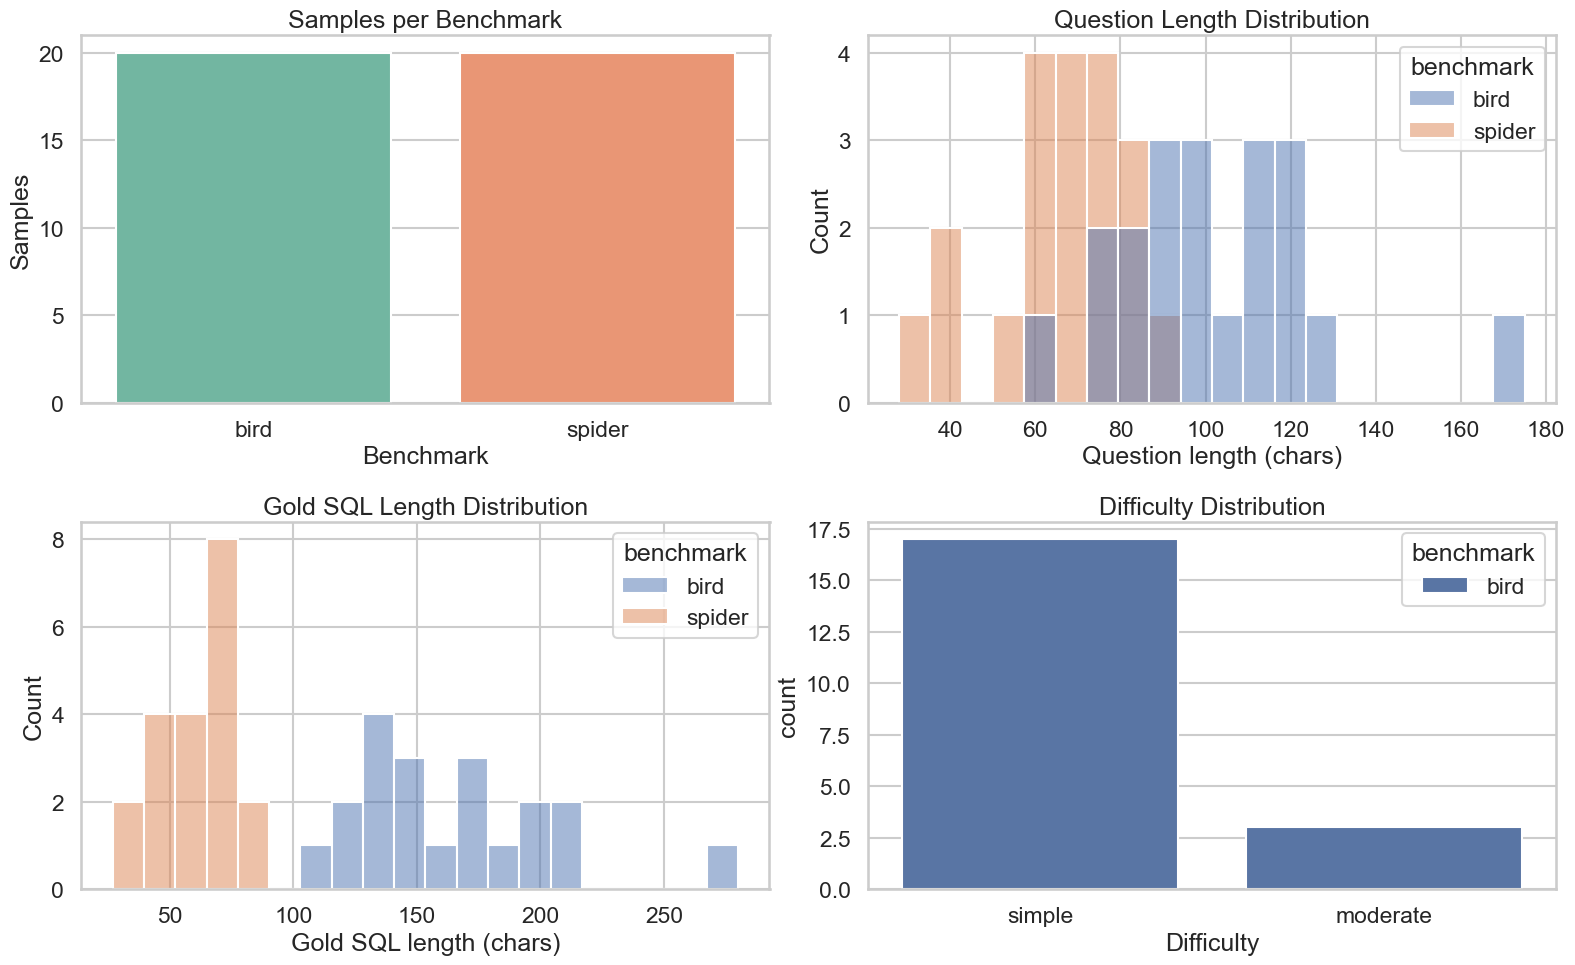

In [3]:
if samples_df.empty:
    raise ValueError('No raw records available.')

unique_samples = (
    samples_df.sort_values(['benchmark', 'sample_id'])
    .drop_duplicates(subset=['benchmark', 'sample_id'])
    .copy()
)

overview = unique_samples.groupby('benchmark').agg(
    n_samples=('sample_id', 'nunique'),
    mean_question_len=('question_len', 'mean'),
    median_question_len=('question_len', 'median'),
    mean_gold_sql_len=('gold_sql_len', 'mean'),
    median_gold_sql_len=('gold_sql_len', 'median'),
)

display(overview.round(2))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.countplot(data=unique_samples, x='benchmark', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Samples per Benchmark')
axes[0, 0].set_xlabel('Benchmark')
axes[0, 0].set_ylabel('Samples')

sns.histplot(data=unique_samples, x='question_len', hue='benchmark', bins=20, multiple='layer', ax=axes[0, 1])
axes[0, 1].set_title('Question Length Distribution')
axes[0, 1].set_xlabel('Question length (chars)')

sns.histplot(data=unique_samples, x='gold_sql_len', hue='benchmark', bins=20, multiple='layer', ax=axes[1, 0])
axes[1, 0].set_title('Gold SQL Length Distribution')
axes[1, 0].set_xlabel('Gold SQL length (chars)')

if unique_samples['difficulty'].notna().any():
    difficulty_df = unique_samples.dropna(subset=['difficulty'])
    sns.countplot(data=difficulty_df, x='difficulty', hue='benchmark', ax=axes[1, 1])
    axes[1, 1].set_title('Difficulty Distribution')
    axes[1, 1].set_xlabel('Difficulty')
else:
    axes[1, 1].axis('off')
    axes[1, 1].text(0.5, 0.5, 'No difficulty labels in current run', ha='center', va='center')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'report_01_dataset_overview.png', dpi=300, bbox_inches='tight')
plt.show()


## 3. Main Results

Основные quality-метрики: `Execution Accuracy` и `Pass@K`. Это главный срез качества генерации SQL.

,model_name,benchmark,execution_accuracy,pass@1,pass@5,pass@10
0,DeepSeek-V3.2,bird,0.40,0.385,0.4500,0.50
1,DeepSeek-V3.2,spider,0.95,0.915,0.9458,0.95
2,SQLCoder-7B,bird,0.00,0.000,0.0000,0.00
3,SQLCoder-7B,spider,0.00,0.000,0.0000,0.00


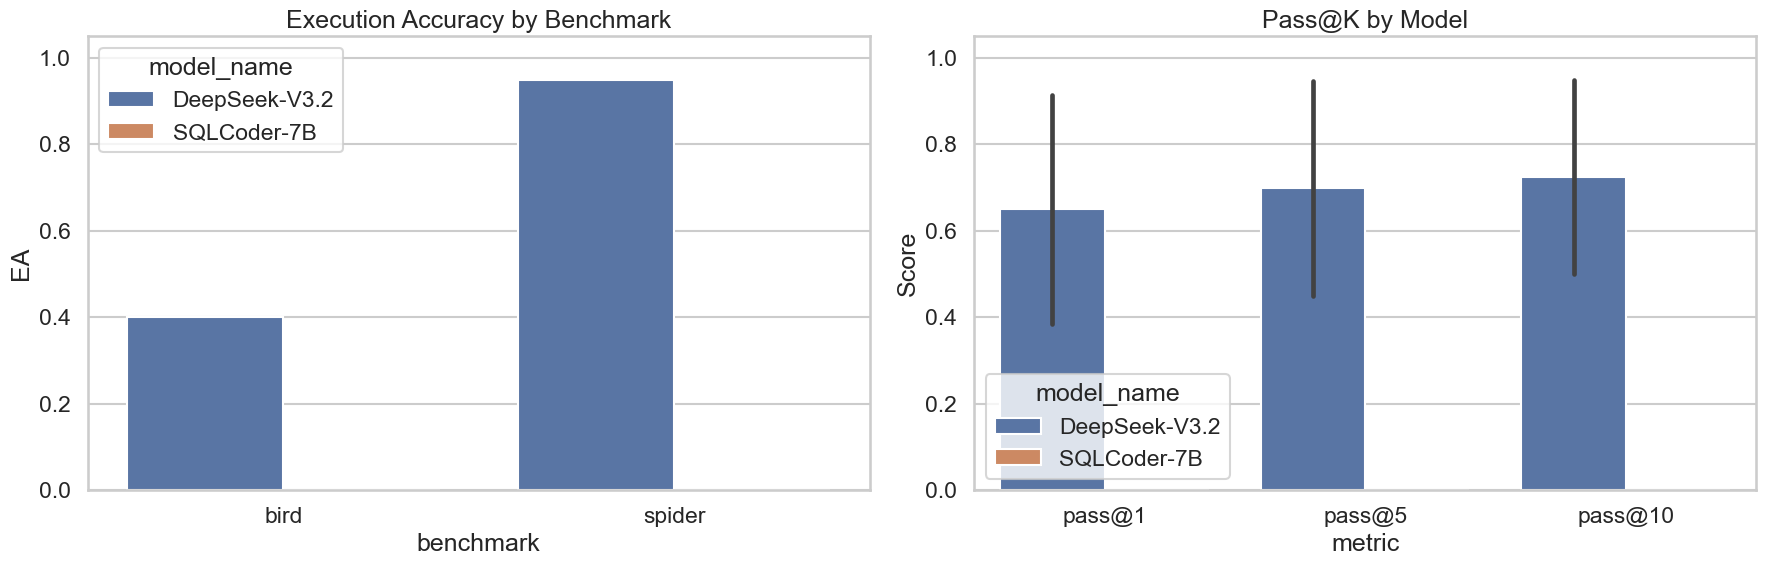

In [4]:
main_metrics = summary_df[['model_name', 'benchmark', 'execution_accuracy', 'pass@1', 'pass@5', 'pass@10']].copy()
display(main_metrics.round(4))

plot_df = summary_df.melt(
    id_vars=['model_name', 'benchmark'],
    value_vars=['execution_accuracy', 'pass@1', 'pass@5', 'pass@10'],
    var_name='metric',
    value_name='score',
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=summary_df, x='benchmark', y='execution_accuracy', hue='model_name', ax=axes[0])
axes[0].set_title('Execution Accuracy by Benchmark')
axes[0].set_ylabel('EA')
axes[0].set_ylim(0, 1.05)

sns.barplot(data=plot_df[plot_df['metric'] != 'execution_accuracy'], x='metric', y='score', hue='model_name', ax=axes[1])
axes[1].set_title('Pass@K by Model')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'report_02_main_results.png', dpi=300, bbox_inches='tight')
plt.show()


## 4. Efficiency

Сравнение по latency, token usage и estimated cost. Этот блок показывает trade-off между качеством и вычислительными затратами.

,model_name,benchmark,Tinf,Tok,Cost,Eff_normalized
0,DeepSeek-V3.2,bird,3340.6985,1082.625,0.0003,NaN
1,DeepSeek-V3.2,spider,2119.4197,350.430,0.0001,NaN
2,SQLCoder-7B,bird,34.2030,1277.400,0.0000,NaN
3,SQLCoder-7B,spider,124.9944,443.860,0.0000,NaN


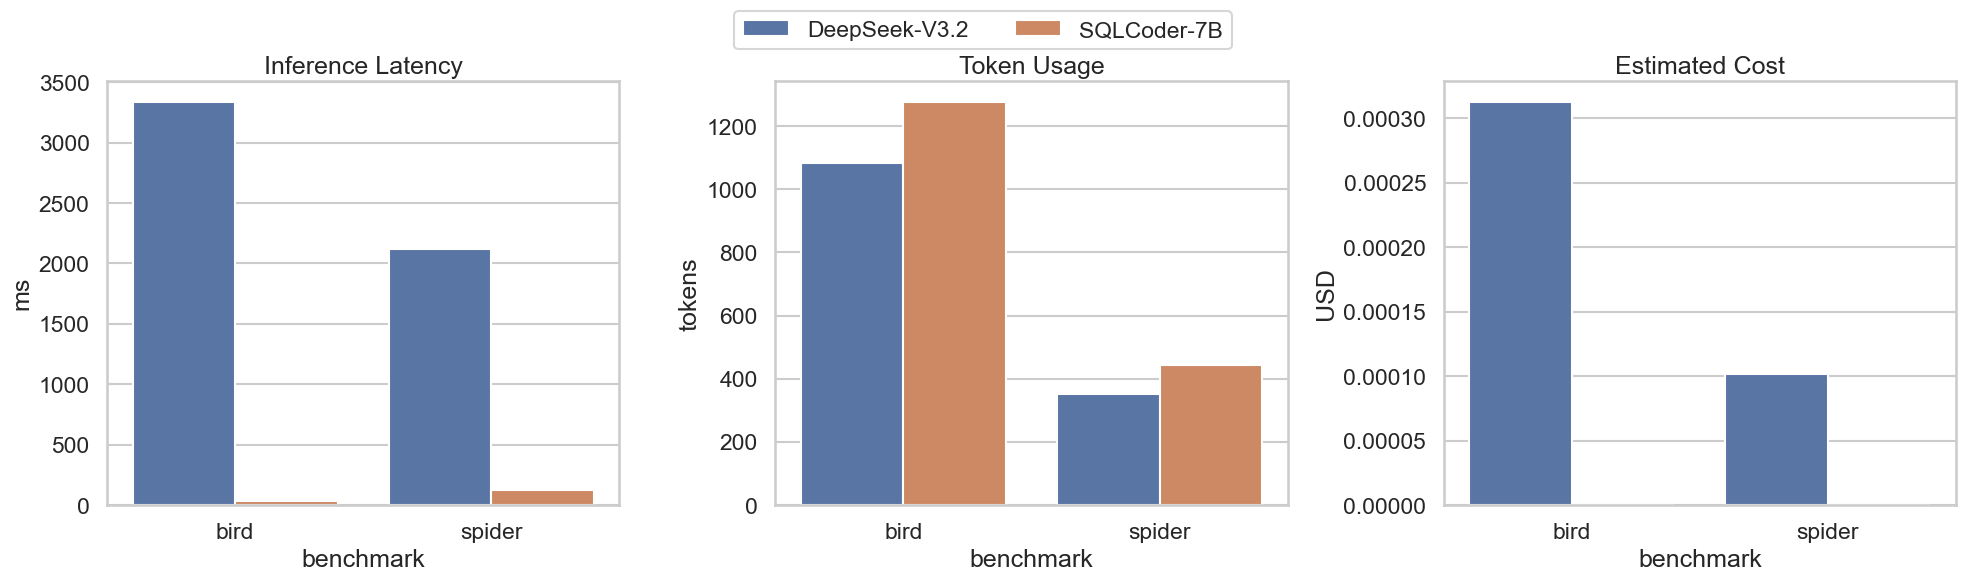

In [5]:
eff_df = summary_df[['model_name', 'benchmark', 'Tinf', 'Tok', 'Cost', 'Eff_normalized']].copy()
display(eff_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(data=summary_df, x='benchmark', y='Tinf', hue='model_name', ax=axes[0])
axes[0].set_title('Inference Latency')
axes[0].set_ylabel('ms')

sns.barplot(data=summary_df, x='benchmark', y='Tok', hue='model_name', ax=axes[1])
axes[1].set_title('Token Usage')
axes[1].set_ylabel('tokens')

sns.barplot(data=summary_df, x='benchmark', y='Cost', hue='model_name', ax=axes[2])
axes[2].set_title('Estimated Cost')
axes[2].set_ylabel('USD')

for ax in axes:
    ax.legend_.remove()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(labels))

plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.savefig(FIGURES_DIR / 'report_03_efficiency_components.png', dpi=300, bbox_inches='tight')
plt.show()

if summary_df['Eff_normalized'].notna().any():
    plt.figure(figsize=(8, 5))
    sns.barplot(data=summary_df, x='benchmark', y='Eff_normalized', hue='model_name')
    plt.title('Normalized Efficiency Score')
    plt.ylabel('Eff_normalized')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'report_04_efficiency_score.png', dpi=300, bbox_inches='tight')
    plt.show()


## 5. Hypothesis-Driven Comparison

Парное сравнение моделей на уровне sample. Здесь видно среднюю разницу в accuracy и bootstrap confidence interval по benchmark.

,benchmark,left_model,right_model,left_accuracy,right_accuracy,accuracy_diff,ci_low,ci_high,left_only_correct,right_only_correct
0,bird,DeepSeek-V3.2,SQLCoder-7B,0.40,0.0,0.40,0.20,0.65,8,0
1,spider,DeepSeek-V3.2,SQLCoder-7B,0.95,0.0,0.95,0.85,1.00,19,0


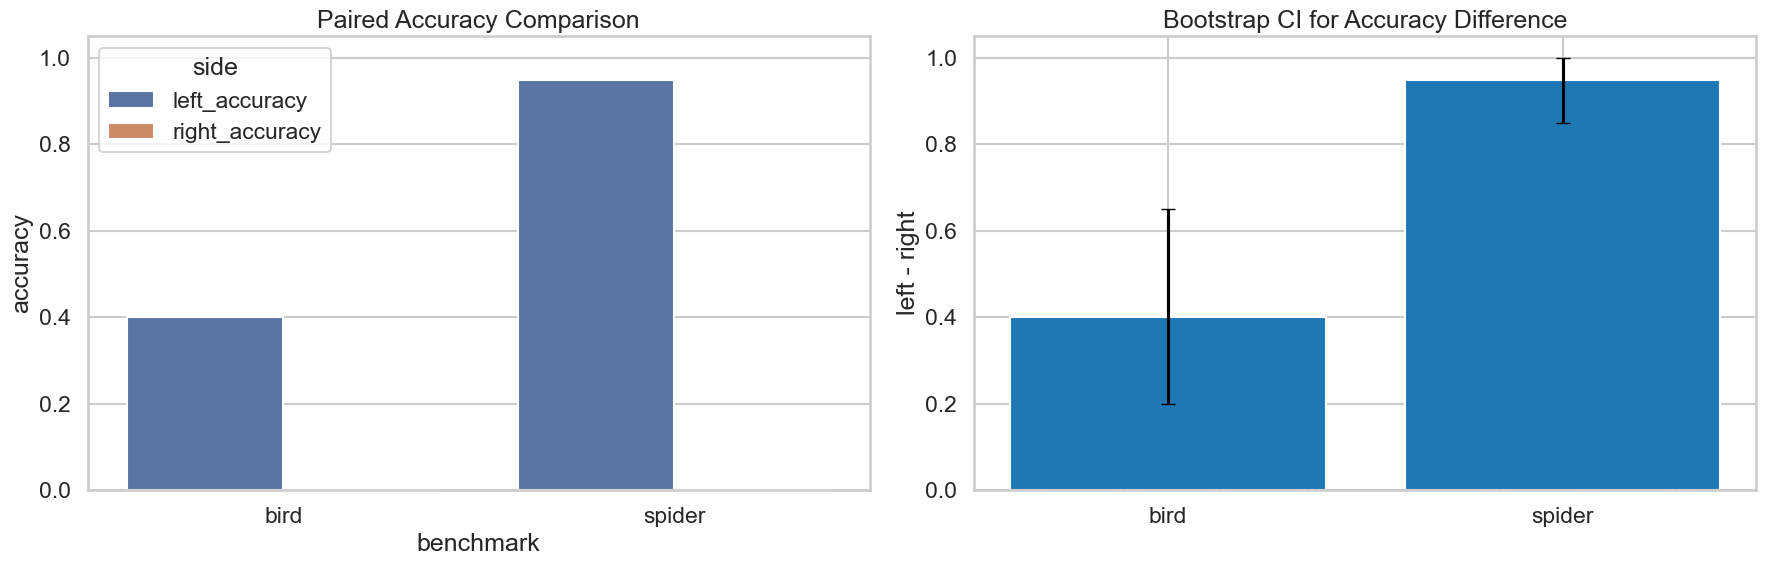

In [6]:
rows = []
for benchmark, group in outcomes_df.groupby('benchmark'):
    pivot = group.pivot_table(index='sample_id', columns='model_name', values='first_hit', aggfunc='first')
    if pivot.shape[1] < 2:
        continue
    left, right = pivot.columns[:2]
    left_vals = pivot[left].astype(bool)
    right_vals = pivot[right].astype(bool)
    diff = float(left_vals.mean() - right_vals.mean())

    diffs = []
    if len(pivot) > 1:
        for _ in range(1000):
            sample = pivot.sample(n=len(pivot), replace=True)
            diffs.append(float(sample[left].mean() - sample[right].mean()))
        ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    else:
        ci_low = ci_high = diff

    rows.append({
        'benchmark': benchmark,
        'left_model': left,
        'right_model': right,
        'left_accuracy': float(left_vals.mean()),
        'right_accuracy': float(right_vals.mean()),
        'accuracy_diff': diff,
        'ci_low': float(ci_low),
        'ci_high': float(ci_high),
        'left_only_correct': int((left_vals & ~right_vals).sum()),
        'right_only_correct': int((~left_vals & right_vals).sum()),
    })

hyp_df = pd.DataFrame(rows)
display(hyp_df.round(4))

if not hyp_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    plot_df = hyp_df.melt(
        id_vars=['benchmark'],
        value_vars=['left_accuracy', 'right_accuracy'],
        var_name='side',
        value_name='accuracy',
    )
    sns.barplot(data=plot_df, x='benchmark', y='accuracy', hue='side', ax=axes[0])
    axes[0].set_title('Paired Accuracy Comparison')
    axes[0].set_ylim(0, 1.05)

    axes[1].bar(hyp_df['benchmark'], hyp_df['accuracy_diff'], color='tab:blue')
    axes[1].errorbar(
        hyp_df['benchmark'],
        hyp_df['accuracy_diff'],
        yerr=[hyp_df['accuracy_diff'] - hyp_df['ci_low'], hyp_df['ci_high'] - hyp_df['accuracy_diff']],
        fmt='none',
        ecolor='black',
        capsize=5,
    )
    axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1)
    axes[1].set_title('Bootstrap CI for Accuracy Difference')
    axes[1].set_ylabel('left - right')

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'report_05_hypothesis.png', dpi=300, bbox_inches='tight')
    plt.show()


## 6. Error Analysis

Разбор sample-level ошибок: типы промахов, overlap между моделями и примеры неуспешных предсказаний.

,sample_id,benchmark,model_name,error_category,first_pred_error
0,bird_0,bird,DeepSeek-V3.2,correct,NaN
1,bird_1,bird,DeepSeek-V3.2,result_mismatch,NaN
2,bird_2,bird,DeepSeek-V3.2,result_mismatch,NaN
3,bird_3,bird,DeepSeek-V3.2,correct,NaN
4,bird_4,bird,DeepSeek-V3.2,result_mismatch,NaN


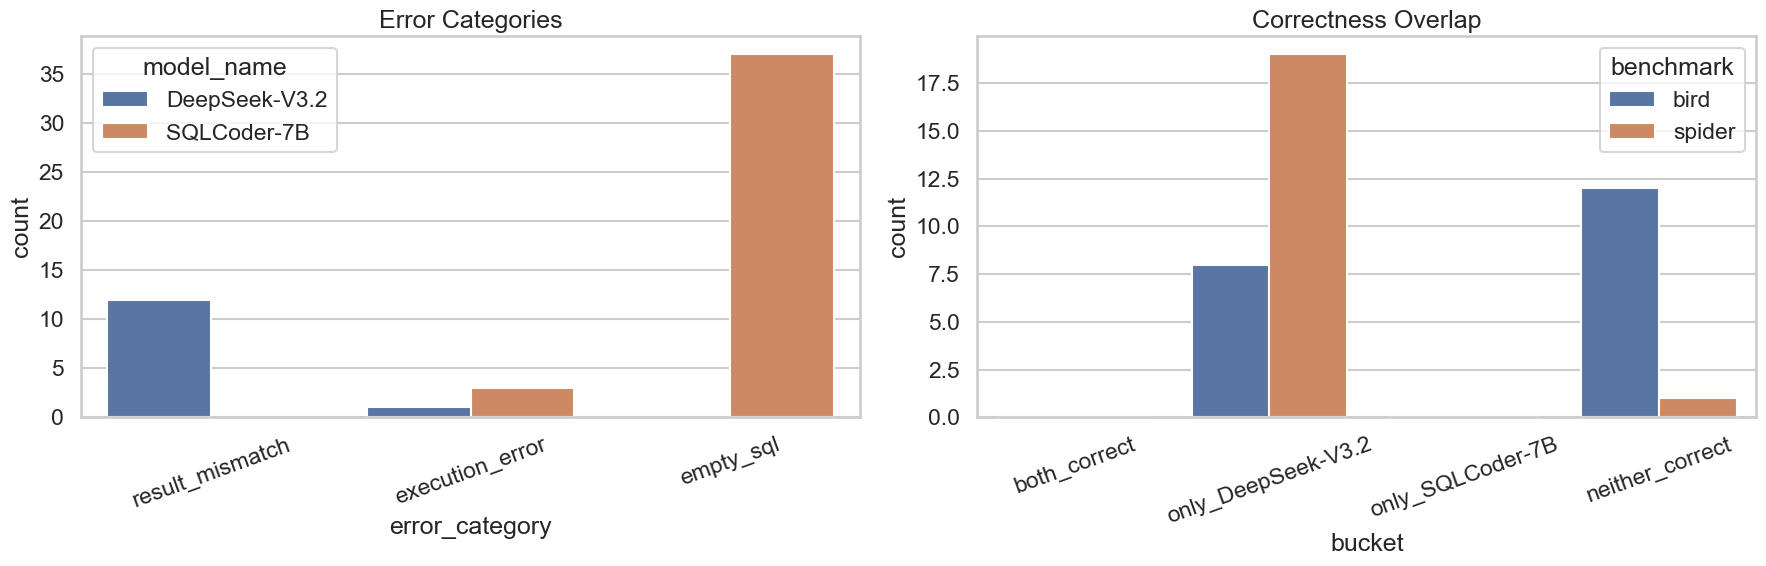

,benchmark,model_name,sample_id,question,gold_sql,first_pred_sql,error_category,first_pred_error
1,bird,DeepSeek-V3.2,bird_1,Please list the lowest three eligible free rat...,SELECT `Free Meal Count (Ages 5-17)` / `Enroll...,"SELECT `School Name`, `Percent (%) Eligible Fr...",result_mismatch,NaN
2,bird,DeepSeek-V3.2,bird_2,Please list the zip code of all the charter sc...,SELECT T2.Zip FROM frpm AS T1 INNER JOIN schoo...,SELECT DISTINCT s.Zip\nFROM schools s\nJOIN fr...,result_mismatch,NaN
4,bird,DeepSeek-V3.2,bird_4,Please list the phone numbers of the direct ch...,SELECT T2.Phone FROM frpm AS T1 INNER JOIN sch...,SELECT s.Phone\nFROM schools s\nWHERE s.Charte...,result_mismatch,NaN
5,bird,DeepSeek-V3.2,bird_5,How many schools with an average score in Math...,SELECT COUNT(DISTINCT T2.School) FROM satscore...,SELECT COUNT(DISTINCT s.CDSCode)\nFROM schools...,result_mismatch,NaN
6,bird,DeepSeek-V3.2,bird_6,Among the schools with the SAT test takers of ...,SELECT T2.School FROM satscores AS T1 INNER JO...,"SELECT DISTINCT s.CDSCode, s.School, s.Distric...",result_mismatch,NaN
11,bird,DeepSeek-V3.2,bird_11,Please list the codes of the schools with a to...,SELECT T2.CDSCode FROM schools AS T1 INNER JOI...,"SELECT CDSCode\nFROM frpm\nWHERE ""Enrollment (...",result_mismatch,NaN
14,bird,DeepSeek-V3.2,bird_14,"List the top five schools, by descending order...",SELECT T1.NCESSchool FROM schools AS T1 INNER ...,"SELECT s.NCESchool, f.`Enrollment (Ages 5-17)`...",execution_error,no such column: s.NCESchool
15,bird,DeepSeek-V3.2,bird_15,Which active district has the highest average ...,SELECT T1.District FROM schools AS T1 INNER JO...,"SELECT s.District, AVG(ss.AvgScrRead) AS avg_r...",result_mismatch,NaN
16,bird,DeepSeek-V3.2,bird_16,How many schools in merged Alameda have number...,SELECT COUNT(T1.CDSCode) FROM schools AS T1 IN...,SELECT COUNT(*)\nFROM satscores\nWHERE cds IN ...,result_mismatch,NaN
17,bird,DeepSeek-V3.2,bird_17,Rank schools by their average score in Writing...,"SELECT CharterNum, AvgScrWrite, RANK() OVER (O...","SELECT s.CDSCode, s.School, s.CharterNum, sats...",result_mismatch,NaN


In [7]:
def categorize(row):
    if row['first_hit']:
        return 'correct'
    if row['empty_sql']:
        return 'empty_sql'
    if not row['first_pred_success']:
        return 'execution_error'
    return 'result_mismatch'

error_df = outcomes_df.copy()
error_df['error_category'] = error_df.apply(categorize, axis=1)

display(error_df[['sample_id', 'benchmark', 'model_name', 'error_category', 'first_pred_error']].head())

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

failures = error_df[error_df['error_category'] != 'correct'].copy()
if failures.empty:
    axes[0].axis('off')
    axes[0].text(0.5, 0.5, 'No failures in current run', ha='center', va='center')
else:
    sns.countplot(data=failures, x='error_category', hue='model_name', ax=axes[0])
    axes[0].set_title('Error Categories')
    axes[0].tick_params(axis='x', rotation=20)

comparison_rows = []
for benchmark, group in error_df.groupby('benchmark'):
    pivot = group.pivot_table(index='sample_id', columns='model_name', values='first_hit', aggfunc='first')
    if pivot.shape[1] < 2:
        continue
    left, right = pivot.columns[:2]
    comparison_rows.extend([
        {'benchmark': benchmark, 'bucket': 'both_correct', 'count': int((pivot[left] & pivot[right]).sum())},
        {'benchmark': benchmark, 'bucket': f'only_{left}', 'count': int((pivot[left] & ~pivot[right]).sum())},
        {'benchmark': benchmark, 'bucket': f'only_{right}', 'count': int((~pivot[left] & pivot[right]).sum())},
        {'benchmark': benchmark, 'bucket': 'neither_correct', 'count': int((~pivot[left] & ~pivot[right]).sum())},
    ])

comparison_df = pd.DataFrame(comparison_rows)
if comparison_df.empty:
    axes[1].axis('off')
    axes[1].text(0.5, 0.5, 'Not enough models for overlap analysis', ha='center', va='center')
else:
    sns.barplot(data=comparison_df, x='bucket', y='count', hue='benchmark', ax=axes[1])
    axes[1].set_title('Correctness Overlap')
    axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'report_06_error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

error_examples = failures[[
    'benchmark', 'model_name', 'sample_id', 'question', 'gold_sql', 'first_pred_sql', 'error_category', 'first_pred_error'
]].head(20)
error_examples


## 7. Expert Score Placeholder

Если экспертная разметка заполнена, здесь будет удобно агрегировать `completeness / efficiency / readability`. Пока ноутбук показывает расположение шаблона и coverage по заполнению.

,sample_id,model_name,benchmark,completeness,efficiency,readability,is_scored
0,bird_0,DeepSeek-V3.2,bird,NaN,NaN,NaN,False
1,bird_1,DeepSeek-V3.2,bird,NaN,NaN,NaN,False
2,bird_2,DeepSeek-V3.2,bird,NaN,NaN,NaN,False
3,bird_3,DeepSeek-V3.2,bird,NaN,NaN,NaN,False
4,bird_4,DeepSeek-V3.2,bird,NaN,NaN,NaN,False


,benchmark,model_name,scored_rows,total_rows,coverage
0,bird,DeepSeek-V3.2,0,20,0.0
1,bird,SQLCoder-7B,0,20,0.0
2,spider,DeepSeek-V3.2,0,20,0.0
3,spider,SQLCoder-7B,0,20,0.0


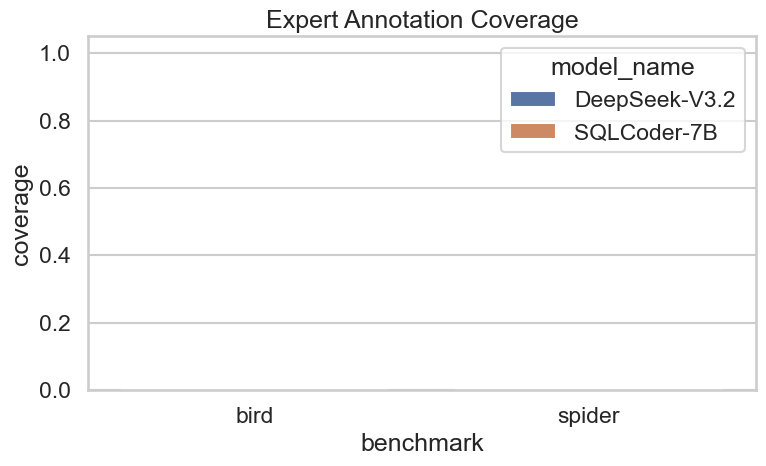

In [8]:
expert_df = pd.read_csv(expert_path) if Path(expert_path).exists() else pd.DataFrame()
score_cols = ['completeness', 'efficiency', 'readability']
for col in score_cols:
    if col not in expert_df.columns:
        expert_df[col] = pd.NA

expert_df['is_scored'] = expert_df[score_cols].notna().all(axis=1) if not expert_df.empty else pd.Series(dtype=bool)
display(expert_df.head())

if not expert_df.empty:
    coverage = (
        expert_df.groupby(['benchmark', 'model_name'])['is_scored']
        .agg(['sum', 'count'])
        .reset_index()
        .rename(columns={'sum': 'scored_rows', 'count': 'total_rows'})
    )
    coverage['coverage'] = coverage['scored_rows'] / coverage['total_rows'].clip(lower=1)
    display(coverage.round(3))

    plt.figure(figsize=(8, 5))
    sns.barplot(data=coverage, x='benchmark', y='coverage', hue='model_name')
    plt.title('Expert Annotation Coverage')
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'report_07_expert_coverage.png', dpi=300, bbox_inches='tight')
    plt.show()


## 8. Conclusions

Краткий итог по текущему прогону: основное качество, вычислительная стоимость и наблюдаемые различия между моделями.

In [9]:
conclusions = summary_df[['model_name', 'benchmark', 'execution_accuracy', 'pass@10', 'Tinf', 'Tok', 'Cost']].copy()
conclusions = conclusions.sort_values(['benchmark', 'execution_accuracy'], ascending=[True, False])
conclusions.round(4)


,model_name,benchmark,execution_accuracy,pass@10,Tinf,Tok,Cost
0,DeepSeek-V3.2,bird,0.40,0.50,3340.6985,1082.625,0.0003
2,SQLCoder-7B,bird,0.00,0.00,34.2030,1277.400,0.0000
1,DeepSeek-V3.2,spider,0.95,0.95,2119.4197,350.430,0.0001
3,SQLCoder-7B,spider,0.00,0.00,124.9944,443.860,0.0000
